In [3]:
import os
import glob
import pandas as pd

BASE_DIR = "../../data/ws/full"  

stations = []

# percorre todas as pastas station_id=*
station_dirs = sorted(glob.glob(os.path.join(BASE_DIR, "station_id=*")))

print(f"Found {len(station_dirs)} station folders")

for station_path in station_dirs:
    # extrai o ID da estação
    station_id = int(station_path.split("station_id=")[1])

    # pega QUALQUER parquet (um ano já basta)
    parquet_files = glob.glob(
        os.path.join(station_path, "year=*/data.parquet")
    )

    if len(parquet_files) == 0:
        print(f"⚠️ No data found for station {station_id}")
        continue

    # abre só UM arquivo e só lat/lon
    df = pd.read_parquet(
        parquet_files[0],
        columns=["latitude", "longitude"]
    )

    # pega o primeiro valor válido
    lat = df["latitude"].iloc[0]
    lon = df["longitude"].iloc[0]

    stations.append({
        "station_id": station_id,
        "lat": lat,
        "lon": lon
    })

stations_df = pd.DataFrame(stations).sort_values("station_id").reset_index(drop=True)

print("\nStations dataframe created:")
print(stations_df.head())
print("\nTotal stations:", len(stations_df))


Found 83 station folders

Stations dataframe created:
   station_id      lat      lon
0           1 -22.8636 -43.2636
1           2 -22.8547 -43.2725
2           3 -22.9327 -43.2567
3           4 -22.8595 -43.2657
4           5 -22.9023 -43.3434

Total stations: 83


In [5]:
import os

eda_dir = "../src/outputs_with_elevation/eda_plots"
os.makedirs(eda_dir, exist_ok=True)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("../../notebooks/sumare_radar/outputs_with_elevation/parquet/calibration_station_14_with_zeros.parquet")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295109 entries, 0 to 295108
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   timestamp    295109 non-null  object 
 1   station_id   295109 non-null  int64  
 2   R            295109 non-null  int64  
 3   G            295109 non-null  int64  
 4   B            295109 non-null  int64  
 5   elevation_m  295109 non-null  float64
 6   m15          295109 non-null  float64
dtypes: float64(2), int64(4), object(1)
memory usage: 15.8+ MB


In [10]:
df[["R", "G", "B", "elevation_m", "m15"]].describe()

,R,G,B,elevation_m,m15
count,295109.000000,295109.000000,295109.000000,295109.0,295109.000000
mean,1.873677,7.080740,0.869608,17.0,0.038375
std,18.365368,34.364892,8.462175,0.0,0.403202
min,0.000000,0.000000,0.000000,17.0,0.000000
25%,0.000000,0.000000,0.000000,17.0,0.000000
50%,0.000000,0.000000,0.000000,17.0,0.000000
75%,0.000000,0.000000,0.000000,17.0,0.000000
max,255.000000,230.000000,230.000000,17.0,36.000000


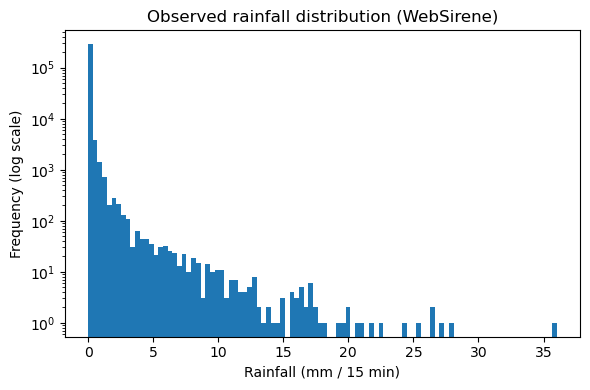

In [11]:
plt.figure(figsize=(6,4))
plt.hist(df["m15"], bins=100)
plt.yscale("log")
plt.xlabel("Rainfall (mm / 15 min)")
plt.ylabel("Frequency (log scale)")
plt.title("Observed rainfall distribution (WebSirene)")
plt.tight_layout()
plt.savefig(
    os.path.join(eda_dir, "rainfall_distribution_log_frequency.png"),
    dpi=150
)
plt.show()

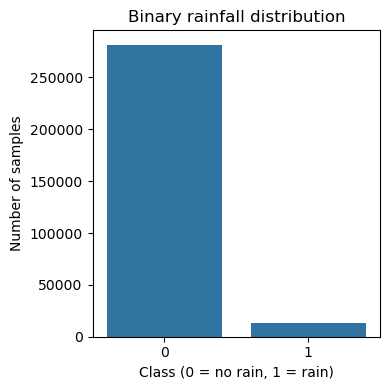

In [12]:
df["rain_binary"] = (df["m15"] > 0.1).astype(int)

plt.figure(figsize=(4,4))
sns.countplot(x="rain_binary", data=df)
plt.xlabel("Class (0 = no rain, 1 = rain)")
plt.ylabel("Number of samples")
plt.title("Binary rainfall distribution")
plt.tight_layout()
plt.savefig(
    os.path.join(eda_dir, "binary_rainfall_distribution.png"),
    dpi=150
)
plt.show()

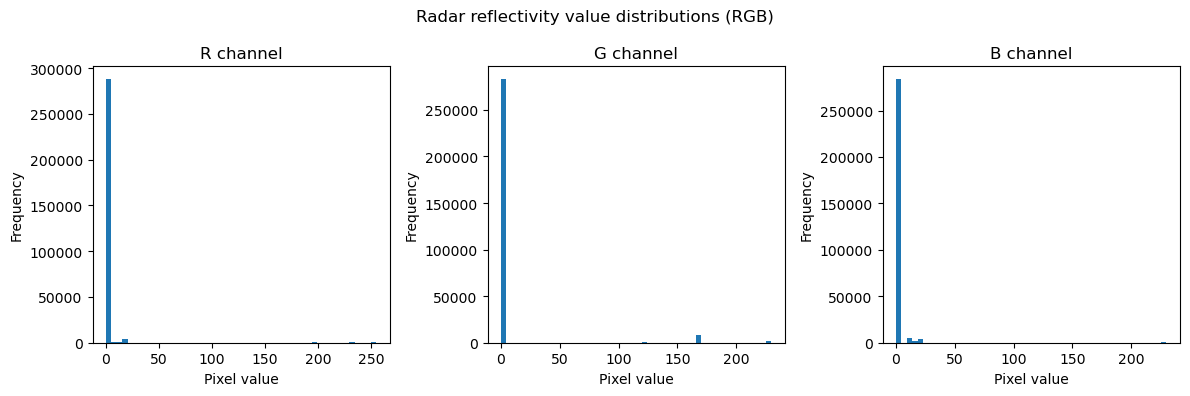

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))

for ax, ch in zip(axes, ["R", "G", "B"]):
    ax.hist(df[ch], bins=50)
    ax.set_title(f"{ch} channel")
    ax.set_xlabel("Pixel value")
    ax.set_ylabel("Frequency")

plt.suptitle("Radar reflectivity value distributions (RGB)")
plt.tight_layout()
plt.savefig(
    os.path.join(eda_dir, "radar_reflectivity_distribution.png"),
    dpi=150
)
plt.show()

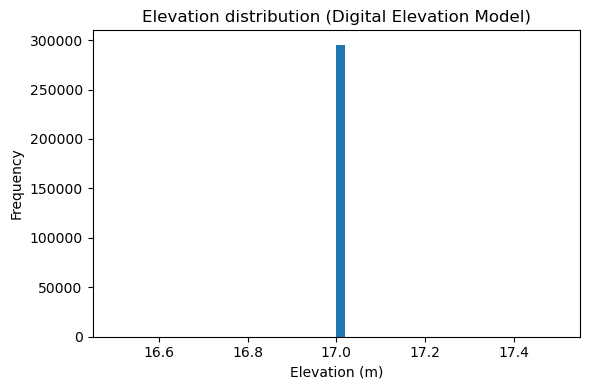

In [14]:
plt.figure(figsize=(6,4))
plt.hist(df["elevation_m"], bins=50)
plt.xlabel("Elevation (m)")
plt.ylabel("Frequency")
plt.title("Elevation distribution (Digital Elevation Model)")
plt.tight_layout()
plt.savefig(
    os.path.join(eda_dir, "elevation_distribution.png"),
    dpi=150
)
plt.show()

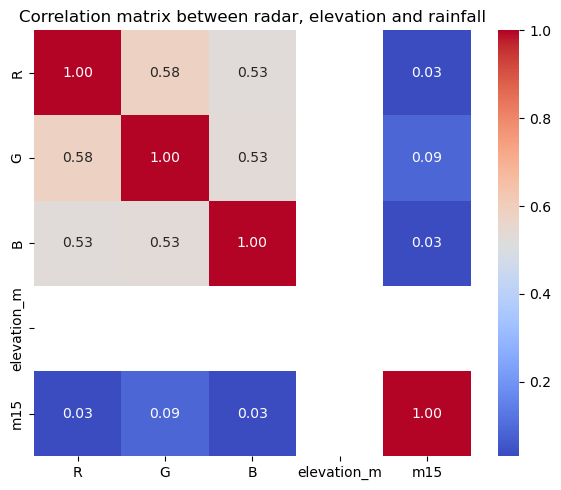

In [15]:
corr = df[["R", "G", "B", "elevation_m", "m15"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix between radar, elevation and rainfall")
plt.tight_layout()
plt.savefig(
    os.path.join(eda_dir, "correlation_radar_elev_rainfall.png"),
    dpi=150
)
plt.show()